# PART-2 Paraphrase Detection 실행 기록

이 노트북은 기존 `paraphrase_detection.py`, `datasets.py`, `evaluation.py` 소스를 import해서 Quora paraphrase detection 실행 결과를 한 곳에 기록하기 위한 용도입니다.

- 체크포인트는 프로젝트 루트의 기존 경로를 사용합니다. 기본값은 `10-1e-05-paraphrase.pt`입니다.
- 예측 결과는 제출 코드와 같은 `predictions/para-dev-output.csv`, `predictions/para-test-output.csv`에 기록됩니다.
- 기본 실행 모드는 기존 체크포인트를 로드해서 dev/test prediction을 다시 생성하는 방식입니다.
- 학습까지 새로 돌릴 때는 설정 셀에서 `RUN_TRAIN = True`로 바꿉니다.


## 1. 프로젝트 루트 준비

노트북을 프로젝트 루트에서 열거나 `notebooks/` 폴더 안에서 열어도 기존 Python 소스들을 import할 수 있도록 작업 디렉터리와 `sys.path`를 맞춥니다.

In [1]:
from pathlib import Path
import os
import sys
import csv
import json
from collections import Counter
from datetime import datetime

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "paraphrase_detection.py").exists():
    candidate = PROJECT_ROOT.parent
    if (candidate / "paraphrase_detection.py").exists():
        PROJECT_ROOT = candidate

assert (PROJECT_ROOT / "paraphrase_detection.py").exists(), (
    "프로젝트 루트 또는 notebooks/ 폴더에서 이 노트북을 실행하세요."
)

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")


Project root: /data1/project/dowon/nlp2026-final


## 2. 기존 소스 코드 불러오기

`paraphrase_detection.py`의 `train()`과 `test()`를 그대로 호출합니다. 노트북에는 실행 설정과 결과 기록만 두고, 모델/데이터셋/평가 로직은 기존 `.py` 파일에 있는 구현을 사용합니다.

In [2]:
from argparse import Namespace
import importlib

import torch

import paraphrase_detection
importlib.reload(paraphrase_detection)
from paraphrase_detection import add_arguments, seed_everything, train, test
from datasets import load_paraphrase_data

print(f"torch: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")


torch: 2.11.0+cu130
cuda available: True


## 3. 실행 설정

아래 값들은 `paraphrase_detection.py`의 CLI 기본값과 맞춰져 있습니다. 현재 체크포인트로 결과만 다시 쓰려면 `RUN_TRAIN = False`, `RUN_TEST = True`를 유지합니다. GPU가 없는 환경에서 CPU 실행을 강제로 허용하려면 `ALLOW_CPU_EXECUTION = True`로 바꾸면 됩니다.

In [3]:
RUN_TRAIN = False
RUN_TEST = True
ALLOW_CPU_EXECUTION = False

MULTI_GPU = torch.cuda.device_count() >= 3
GPU_IDS = "1,2,3" if torch.cuda.device_count() >= 4 else None

CHECKPOINT_PATH = None  # None이면 script와 같은 규칙으로 checkpoint 이름을 만듭니다.

args = Namespace(
    para_train="data/quora-train.csv",
    para_dev="data/quora-dev.csv",
    para_test="data/quora-test-student.csv",
    para_dev_out="predictions/para-dev-output.csv",
    para_test_out="predictions/para-test-output.csv",
    seed=11711,
    epochs=10,
    use_gpu=torch.cuda.is_available(),
    multi_gpu=MULTI_GPU,
    gpu_ids=GPU_IDS,
    bidirectional_eval=False,
    prompt_template="paraphrase",
    prompt_ensemble_eval=False,
    prompt_ensemble_templates="paraphrase,duplicate,equivalent",
    threshold=None,
    tune_threshold=False,
    skip_train=not RUN_TRAIN,
    override_checkpoint_eval_args=False,
    augment_swap=False,
    hard_negative_weight=1.0,
    hard_negative_jaccard=0.6,
    class_weighting=False,
    classification_head=False,
    hidden_dropout_prob=0.1,
    grad_clip=0.0,
    weight_decay=0.0,
    early_stopping_patience=0,
    batch_size=512 if MULTI_GPU else 128,
    lr=1e-5,
    model_size="gpt2",
)

def build_checkpoint_path(run_args):
    parts = [str(run_args.epochs), str(run_args.lr)]
    if run_args.classification_head:
        parts.append("linear")
    if run_args.augment_swap:
        parts.append("swap")
    if run_args.hard_negative_weight > 1.0:
        parts.append("hardneg")
    if run_args.class_weighting:
        parts.append("classweight")
    return "-".join(parts + ["paraphrase.pt"])

args.filepath = CHECKPOINT_PATH or build_checkpoint_path(args)
args = add_arguments(args)
seed_everything(args.seed)

config_summary = {
    "run_train": RUN_TRAIN,
    "run_test": RUN_TEST,
    "device": "cuda" if args.use_gpu else "cpu",
    "multi_gpu": args.multi_gpu,
    "gpu_ids": args.gpu_ids,
    "visible_gpus": torch.cuda.device_count(),
    "allow_cpu_execution": ALLOW_CPU_EXECUTION,
    "checkpoint": args.filepath,
    "dev_output": args.para_dev_out,
    "test_output": args.para_test_out,
    "seed": args.seed,
    "epochs": args.epochs,
    "batch_size": args.batch_size,
    "learning_rate": args.lr,
    "model_size": args.model_size,
}
print(json.dumps(config_summary, indent=2, ensure_ascii=False))


{
  "run_train": false,
  "run_test": true,
  "device": "cuda",
  "multi_gpu": true,
  "gpu_ids": "1,2,3",
  "visible_gpus": 4,
  "allow_cpu_execution": false,
  "checkpoint": "10-1e-05-paraphrase.pt",
  "dev_output": "predictions/para-dev-output.csv",
  "test_output": "predictions/para-test-output.csv",
  "seed": 11711,
  "epochs": 10,
  "batch_size": 512,
  "learning_rate": 1e-05,
  "model_size": "gpt2"
}


## 4. 데이터와 산출물 확인

학습/평가를 시작하기 전에 Quora 데이터 파일, 체크포인트, 기존 prediction 파일이 예상 위치에 있는지 확인합니다. 이 셀은 모델을 실행하지 않고 파일 상태만 기록합니다.

In [4]:
def file_status(path):
    path = PROJECT_ROOT / path
    if not path.exists():
        return {"path": str(path.relative_to(PROJECT_ROOT)), "exists": False}
    return {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": True,
        "size_mb": round(path.stat().st_size / (1024 * 1024), 3),
        "modified": datetime.fromtimestamp(path.stat().st_mtime).isoformat(timespec="seconds"),
    }

artifact_status = [
    file_status(args.para_train),
    file_status(args.para_dev),
    file_status(args.para_test),
    file_status(args.filepath),
    file_status(args.para_dev_out),
    file_status(args.para_test_out),
]
print(json.dumps(artifact_status, indent=2, ensure_ascii=False))


[
  {
    "path": "data/quora-train.csv",
    "exists": true,
    "size_mb": 46.035,
    "modified": "2026-06-08T18:48:40"
  },
  {
    "path": "data/quora-dev.csv",
    "exists": true,
    "size_mb": 6.577,
    "modified": "2026-06-08T18:48:40"
  },
  {
    "path": "data/quora-test-student.csv",
    "exists": true,
    "size_mb": 12.863,
    "modified": "2026-06-08T18:48:40"
  },
  {
    "path": "10-1e-05-paraphrase.pt",
    "exists": true,
    "size_mb": 1431.072,
    "modified": "2026-06-08T22:19:40"
  },
  {
    "path": "predictions/para-dev-output.csv",
    "exists": true,
    "size_mb": 1.802,
    "modified": "2026-06-08T22:49:49"
  },
  {
    "path": "predictions/para-test-output.csv",
    "exists": true,
    "size_mb": 3.603,
    "modified": "2026-06-08T22:49:49"
  }
]


## 5. 데이터 로딩 기록

기존 `load_paraphrase_data()` 함수를 사용해서 train/dev/test split을 읽고, 레이블 분포를 간단히 확인합니다. 이 단계도 모델 forward pass는 수행하지 않습니다.

In [5]:
train_data = load_paraphrase_data(args.para_train)
dev_data = load_paraphrase_data(args.para_dev)
test_data = load_paraphrase_data(args.para_test, split="test")

label_counts = {
    "train": dict(Counter(example[2] for example in train_data)),
    "dev": dict(Counter(example[2] for example in dev_data)),
}
data_summary = {
    "train_examples": len(train_data),
    
    "dev_examples": len(dev_data),
    "test_examples": len(test_data),
    "label_counts": label_counts,
}
print(json.dumps(data_summary, indent=2, ensure_ascii=False))


Loaded 283003 train examples from data/quora-train.csv
Loaded 40429 train examples from data/quora-dev.csv
Loaded 80858 test examples from data/quora-test-student.csv
{
  "train_examples": 283003,
  "dev_examples": 40429,
  "test_examples": 80858,
  "label_counts": {
    "train": {
      "1": 104579,
      "0": 178424
    },
    "dev": {
      "0": 25537,
      "1": 14892
    }
  }
}


## 6. 기존 prediction 파일 요약

이미 만들어진 `predictions/para-*.csv` 파일의 행 수와 예측 라벨 분포를 확인합니다. 모델을 다시 실행하기 전후의 결과가 같은지 비교할 때 이 셀의 출력이 기준 기록이 됩니다.

In [6]:
def summarize_prediction_file(path, preview_rows=5):
    path = PROJECT_ROOT / path
    if not path.exists():
        return {"path": str(path.relative_to(PROJECT_ROOT)), "exists": False}

    label_counts = Counter()
    preview = []
    total_rows = 0
    with path.open(newline="") as fp:
        reader = csv.DictReader(fp)
        for row in reader:
            total_rows += 1
            label_counts[row.get("Predicted_Is_Paraphrase", "")] += 1
            if len(preview) < preview_rows:
                preview.append(row)

    return {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": True,
        "rows": total_rows,
        "label_counts": dict(label_counts),
        "preview": preview,
    }

prediction_summary_before = {
    "recorded_at": datetime.now().isoformat(timespec="seconds"),
    "dev": summarize_prediction_file(args.para_dev_out),
    "test": summarize_prediction_file(args.para_test_out),
}
print(json.dumps(prediction_summary_before, indent=2, ensure_ascii=False))


{
  "recorded_at": "2026-06-08T22:54:14",
  "dev": {
    "path": "predictions/para-dev-output.csv",
    "exists": true,
    "rows": 40429,
    "label_counts": {
      "0": 24405,
      "1": 16024
    },
    "preview": [
      {
        "id": "65977 641bc8de-b905-4ae4-a0ee-abea15fbc88e",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "176826 a9b4a342-5a5c-4f99-a104-9d1c4f26e0ab",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "77211 fc32b44b-5288-48c5-b66d-a8342838b907",
        "Predicted_Is_Paraphrase": "1"
      },
      {
        "id": "382066 460899e7-a67f-41db-b204-e2d77f8efb78",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "237122 b3549639-8557-4848-9ea7-c48b27dcdb39",
        "Predicted_Is_Paraphrase": "1"
      }
    ]
  },
  "test": {
    "path": "predictions/para-test-output.csv",
    "exists": true,
    "rows": 80858,
    "label_counts": {
      "1": 32290,
      "0": 48568
    },
    "preview": [
      {

## 7. 학습 및 평가 실행

이 셀에서 기존 `train(args)`와 `test(args)`를 호출합니다. `RUN_TRAIN = False`이면 checkpoint 학습은 건너뛰고, `RUN_TEST = True`이면 현재 checkpoint를 로드해 dev/test prediction을 생성합니다. GPU가 없는 환경에서 실수로 긴 CPU 실행이 시작되지 않도록 기본 설정에서는 CPU 실행을 막아둡니다.

In [7]:
def require_runtime_device():
    if (RUN_TRAIN or RUN_TEST) and not args.use_gpu and not ALLOW_CPU_EXECUTION:
        raise RuntimeError(
            "GPU가 감지되지 않았습니다. GPU 없이 실행하려면 ALLOW_CPU_EXECUTION = True로 바꾸세요. "
            "단, paraphrase 모델 실행은 CPU에서 매우 오래 걸릴 수 있습니다."
        )

require_runtime_device()

if RUN_TRAIN:
    train(args)
else:
    print("Training skipped. Existing checkpoint will be used.")

if RUN_TEST:
    test(args)
else:
    print("Prediction generation skipped.")


Training skipped. Existing checkpoint will be used.
Using DataParallel on CUDA devices: [1, 2, 3]
Loaded model to test from 10-1e-05-paraphrase.pt
Loaded 40429 train examples from data/quora-dev.csv
Loaded 80858 test examples from data/quora-test-student.csv


eval:   1%|          | 1/158 [00:00<00:30,  5.18it/s]

dev paraphrase acc :: 0.879


eval: 100%|██████████| 158/158 [00:30<00:00,  5.25it/s]


## 8. 실행 후 prediction 요약

`test(args)` 실행 후 같은 요약 함수를 다시 호출해서 새로 생성된 prediction 파일 상태를 기록합니다. 이 출력은 제출 직전 결과 확인용으로 남깁니다.

In [8]:
prediction_summary_after = {
    "recorded_at": datetime.now().isoformat(timespec="seconds"),
    "checkpoint": file_status(args.filepath),
    "dev": summarize_prediction_file(args.para_dev_out),
    "test": summarize_prediction_file(args.para_test_out),
}
print(json.dumps(prediction_summary_after, indent=2, ensure_ascii=False))


{
  "recorded_at": "2026-06-08T22:55:03",
  "checkpoint": {
    "path": "10-1e-05-paraphrase.pt",
    "exists": true,
    "size_mb": 1431.072,
    "modified": "2026-06-08T22:19:40"
  },
  "dev": {
    "path": "predictions/para-dev-output.csv",
    "exists": true,
    "rows": 40429,
    "label_counts": {
      "0": 24405,
      "1": 16024
    },
    "preview": [
      {
        "id": "65977 641bc8de-b905-4ae4-a0ee-abea15fbc88e",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "176826 a9b4a342-5a5c-4f99-a104-9d1c4f26e0ab",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "77211 fc32b44b-5288-48c5-b66d-a8342838b907",
        "Predicted_Is_Paraphrase": "1"
      },
      {
        "id": "382066 460899e7-a67f-41db-b204-e2d77f8efb78",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "237122 b3549639-8557-4848-9ea7-c48b27dcdb39",
        "Predicted_Is_Paraphrase": "1"
      }
    ]
  },
  "test": {
    "path": "predictions/para-t

## 9. 모델 성능 평가

PDF 기준으로 Paraphrase Detection은 accuracy를 평가 지표로 사용합니다. 로컬에서는 라벨이 있는 dev split으로 accuracy와 macro-F1을 계산하고, test-student split은 라벨이 없으므로 prediction 파일 생성 여부와 라벨 분포만 확인합니다.


In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support

def load_dev_labels(path):
    labels = {}
    with open(PROJECT_ROOT / path, newline="") as f:
        reader = csv.DictReader(f, delimiter="	")
        for row in reader:
            labels[row["id"].lower().strip()] = int(float(row["is_duplicate"]))
    return labels

def load_paraphrase_predictions(path):
    predictions = {}
    with open(PROJECT_ROOT / path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            predictions[row["id"].lower().strip()] = int(row["Predicted_Is_Paraphrase"])
    return predictions

def summarize_prediction_file_for_eval(path, preview_rows=5):
    path = PROJECT_ROOT / path
    if not path.exists():
        return {"path": str(path.relative_to(PROJECT_ROOT)), "exists": False}

    label_counts = Counter()
    preview = []
    total_rows = 0
    with path.open(newline="") as fp:
        reader = csv.DictReader(fp)
        for row in reader:
            total_rows += 1
            label_counts[row.get("Predicted_Is_Paraphrase", "")] += 1
            if len(preview) < preview_rows:
                preview.append(row)

    return {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": True,
        "rows": total_rows,
        "label_counts": dict(label_counts),
        "preview": preview,
    }

dev_labels = load_dev_labels(args.para_dev)
dev_predictions = load_paraphrase_predictions(args.para_dev_out)
matched_ids = [sent_id for sent_id in dev_labels if sent_id in dev_predictions]
missing_prediction_ids = sorted(set(dev_labels) - set(dev_predictions))[:10]
extra_prediction_ids = sorted(set(dev_predictions) - set(dev_labels))[:10]

if not matched_ids:
    raise RuntimeError("No matching dev ids between labels and predictions. Run test(args) first.")

y_true = [dev_labels[sent_id] for sent_id in matched_ids]
y_pred = [dev_predictions[sent_id] for sent_id in matched_ids]
precision, recall, f1_by_label, support = precision_recall_fscore_support(
    y_true, y_pred, labels=[0, 1], zero_division=0
)

evaluation_summary = {
    "recorded_at": datetime.now().isoformat(timespec="seconds"),
    "checkpoint": args.filepath,
    "dev_examples": len(dev_labels),
    "dev_predictions": len(dev_predictions),
    "matched_examples": len(matched_ids),
    "missing_prediction_count": len(set(dev_labels) - set(dev_predictions)),
    "missing_prediction_examples": missing_prediction_ids,
    "extra_prediction_count": len(set(dev_predictions) - set(dev_labels)),
    "extra_prediction_examples": extra_prediction_ids,
    "accuracy": accuracy_score(y_true, y_pred),
    "macro_f1": f1_score(y_true, y_pred, average="macro"),
    "label_metrics": {
        "0_not_paraphrase": {
            "precision": precision[0],
            "recall": recall[0],
            "f1": f1_by_label[0],
            "support": int(support[0]),
        },
        "1_paraphrase": {
            "precision": precision[1],
            "recall": recall[1],
            "f1": f1_by_label[1],
            "support": int(support[1]),
        },
    },
    "confusion_matrix_rows_true_cols_pred_0_1": confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist(),
    "dev_prediction_counts": dict(Counter(y_pred)),
    "test_prediction_file": summarize_prediction_file_for_eval(args.para_test_out),
}
print(json.dumps(evaluation_summary, indent=2, ensure_ascii=False))


{
  "recorded_at": "2026-06-08T22:55:04",
  "checkpoint": "10-1e-05-paraphrase.pt",
  "dev_examples": 40429,
  "dev_predictions": 40429,
  "matched_examples": 40429,
  "missing_prediction_count": 0,
  "missing_prediction_examples": [],
  "extra_prediction_count": 0,
  "extra_prediction_examples": [],
  "accuracy": 0.8788493408197087,
  "macro_f1": 0.8717484710780484,
  "label_metrics": {
    "0_not_paraphrase": {
      "precision": 0.9228436795738578,
      "recall": 0.8819360144104632,
      "f1": 0.9019262344319411,
      "support": 25537
    },
    "1_paraphrase": {
      "precision": 0.8118447329006491,
      "recall": 0.873556271823798,
      "f1": 0.8415707077241558,
      "support": 14892
    }
  },
  "confusion_matrix_rows_true_cols_pred_0_1": [
    [
      22522,
      3015
    ],
    [
      1883,
      13009
    ]
  ],
  "dev_prediction_counts": {
    "0": 24405,
    "1": 16024
  },
  "test_prediction_file": {
    "path": "predictions/para-test-output.csv",
    "exists": tru

## 10. Zero-Shot Baseline

PART-1에서 구현한 `GPT2Model`에 pretrained GPT-2 weight만 로드하고, Quora dev 전체 split에 대해 fine-tuning 없이 cloze-style `yes`/`no` 예측을 수행합니다. 이 셀은 test-student split을 평가에 사용하지 않습니다.


In [10]:
from torch.utils.data import DataLoader
from datasets import ParaphraseDetectionDataset
from evaluation import model_eval_paraphrase
from paraphrase_detection import ParaphraseGPT

ZERO_SHOT_DEV_OUT = "predictions/para-dev-zero-shot-output.csv"
ZERO_SHOT_GPU_ID = "0" if torch.cuda.is_available() else None

zero_shot_args = Namespace(**vars(args))
zero_shot_args.use_gpu = torch.cuda.is_available()
zero_shot_args.multi_gpu = False
zero_shot_args.gpu_ids = ZERO_SHOT_GPU_ID
zero_shot_args.batch_size = args.batch_size
zero_shot_args = add_arguments(zero_shot_args)

zero_shot_device = torch.device(f"cuda:{ZERO_SHOT_GPU_ID}" if ZERO_SHOT_GPU_ID is not None else "cpu")
zero_shot_model = ParaphraseGPT(zero_shot_args).to(zero_shot_device)
zero_shot_model.eval()

zero_shot_dev_data = load_paraphrase_data(zero_shot_args.para_dev)
zero_shot_dev_dataset = ParaphraseDetectionDataset(zero_shot_dev_data, zero_shot_args)
zero_shot_dev_loader = DataLoader(
    zero_shot_dev_dataset,
    shuffle=False,
    batch_size=zero_shot_args.batch_size,
    collate_fn=zero_shot_dev_dataset.collate_fn,
)

zero_acc, zero_f1, zero_pred, zero_true, zero_ids = model_eval_paraphrase(
    zero_shot_dev_loader,
    zero_shot_model,
    zero_shot_device,
    bidirectional=False,
)

with open(PROJECT_ROOT / ZERO_SHOT_DEV_OUT, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "Predicted_Is_Paraphrase"])
    writer.writerows(zip(zero_ids, zero_pred))

zero_true = [int(label) for label in zero_true]
zero_pred = [int(label) for label in zero_pred]

zero_shot_confusion = confusion_matrix(zero_true, zero_pred, labels=[0, 1]).tolist()
zero_precision, zero_recall, zero_f1_by_label, zero_support = precision_recall_fscore_support(
    zero_true, zero_pred, labels=[0, 1], zero_division=0
)

zero_shot_summary = {
    "recorded_at": datetime.now().isoformat(timespec="seconds"),
    "setting": "PART-1 GPT2Model + pretrained GPT-2 weights, no Quora fine-tuning",
    "device": str(zero_shot_device),
    "dev_examples": len(zero_true),
    "accuracy": zero_acc,
    "macro_f1": zero_f1,
    "label_metrics": {
        "0_not_paraphrase": {
            "precision": zero_precision[0],
            "recall": zero_recall[0],
            "f1": zero_f1_by_label[0],
            "support": int(zero_support[0]),
        },
        "1_paraphrase": {
            "precision": zero_precision[1],
            "recall": zero_recall[1],
            "f1": zero_f1_by_label[1],
            "support": int(zero_support[1]),
        },
    },
    "confusion_matrix_rows_true_cols_pred_0_1": zero_shot_confusion,
    "dev_prediction_counts": dict(Counter(zero_pred)),
    "dev_prediction_file": ZERO_SHOT_DEV_OUT,
}
print(json.dumps(zero_shot_summary, indent=2, ensure_ascii=False))


Loaded 40429 train examples from data/quora-dev.csv


eval: 100%|██████████| 79/79 [00:24<00:00,  3.28it/s]

{
  "recorded_at": "2026-06-08T22:55:30",
  "setting": "PART-1 GPT2Model + pretrained GPT-2 weights, no Quora fine-tuning",
  "device": "cuda:0",
  "dev_examples": 40429,
  "accuracy": 0.3683494521259492,
  "macro_f1": 0.26919253086531336,
  "label_metrics": {
    "0_not_paraphrase": {
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "support": 25537
    },
    "1_paraphrase": {
      "precision": 0.3683494521259492,
      "recall": 1.0,
      "f1": 0.5383850617306267,
      "support": 14892
    }
  },
  "confusion_matrix_rows_true_cols_pred_0_1": [
    [
      0,
      25537
    ],
    [
      0,
      14892
    ]
  ],
  "dev_prediction_counts": {
    "1": 40429
  },
  "dev_prediction_file": "predictions/para-dev-zero-shot-output.csv"
}


## 11. 성능 비교 시각화

Fine-tuned checkpoint와 zero-shot baseline의 dev accuracy/macro-F1, confusion matrix, 예측 라벨 분포를 비교합니다. 모든 수치는 전체 dev split 기준입니다.


,model,accuracy,macro_f1,pred_0,pred_1
0,Fine-tuned,0.878849,0.871748,24405,16024
1,Zero-shot,0.368349,0.269193,0,40429


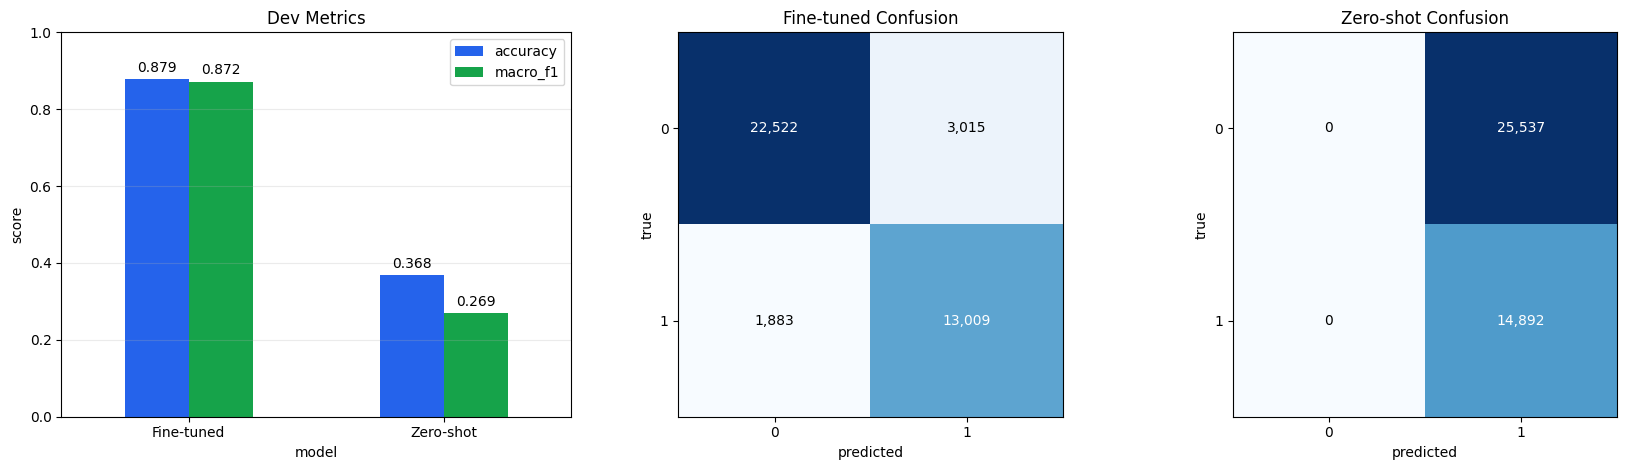

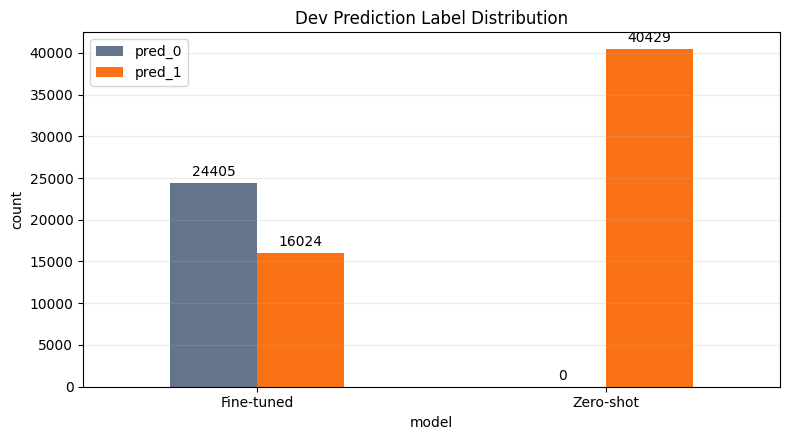

In [11]:
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

if "evaluation_summary" not in globals():
    raise RuntimeError("Run the model performance evaluation cell first.")
if "zero_shot_summary" not in globals():
    raise RuntimeError("Run the zero-shot baseline cell first.")

comparison_df = pd.DataFrame([
    {
        "model": "Fine-tuned",
        "accuracy": evaluation_summary["accuracy"],
        "macro_f1": evaluation_summary["macro_f1"],
        "pred_0": evaluation_summary["dev_prediction_counts"].get(0, 0),
        "pred_1": evaluation_summary["dev_prediction_counts"].get(1, 0),
    },
    {
        "model": "Zero-shot",
        "accuracy": zero_shot_summary["accuracy"],
        "macro_f1": zero_shot_summary["macro_f1"],
        "pred_0": zero_shot_summary["dev_prediction_counts"].get(0, 0),
        "pred_1": zero_shot_summary["dev_prediction_counts"].get(1, 0),
    },
])
display(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

comparison_df.set_index("model")[["accuracy", "macro_f1"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#2563eb", "#16a34a"],
    rot=0,
)
axes[0].set_ylim(0, 1)
axes[0].set_title("Dev Metrics")
axes[0].set_ylabel("score")
axes[0].grid(axis="y", alpha=0.25)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3)

def plot_confusion(ax, matrix, title):
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_xticks([0, 1], labels=["0", "1"])
    ax.set_yticks([0, 1], labels=["0", "1"])
    max_value = max(max(row) for row in matrix)
    for i, row in enumerate(matrix):
        for j, value in enumerate(row):
            color = "white" if value > max_value * 0.55 else "black"
            ax.text(j, i, f"{value:,}", ha="center", va="center", color=color)
    return image

plot_confusion(
    axes[1],
    evaluation_summary["confusion_matrix_rows_true_cols_pred_0_1"],
    "Fine-tuned Confusion",
)
plot_confusion(
    axes[2],
    zero_shot_summary["confusion_matrix_rows_true_cols_pred_0_1"],
    "Zero-shot Confusion",
)
plt.tight_layout()
plt.show()

label_df = comparison_df.set_index("model")[["pred_0", "pred_1"]]
ax = label_df.plot(kind="bar", figsize=(8, 4.5), color=["#64748b", "#f97316"], rot=0)
ax.set_title("Dev Prediction Label Distribution")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
plt.show()


## 12. 실행 메모

- 실행일: 25.06.08
- 실행 환경: RTX PRO 6000 Blackwell 3ea
- dev paraphrase acc : 0.878849


